<a href="https://colab.research.google.com/github/PabloDuranLopez/Miprogresionypraticas/blob/main/KernelRegresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2164]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2165]:
np.random.seed(123)

In [2166]:
N=40
x=np.sort(np.random.rand(N))
e=np.random.normal(0,0.02,N)
y=np.sin(2*np.pi*x)+e


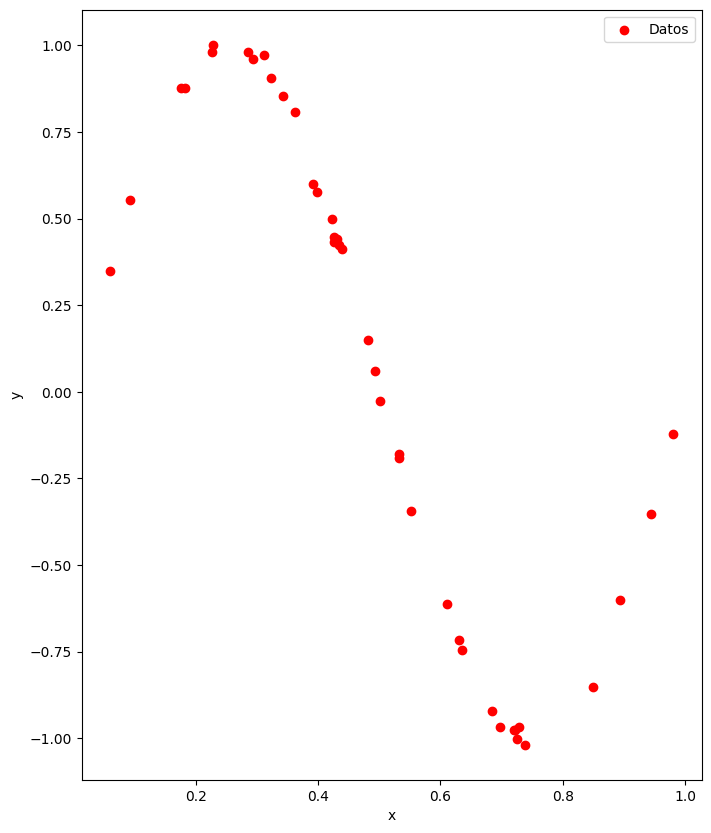

In [2167]:

plt.figure(figsize=(8,10))
plt.scatter(x,y,color="red",label="Datos")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [2168]:
def RBF(x,centro, sigma):
  return np.exp(-(x-centro)**2/(2*sigma**2))


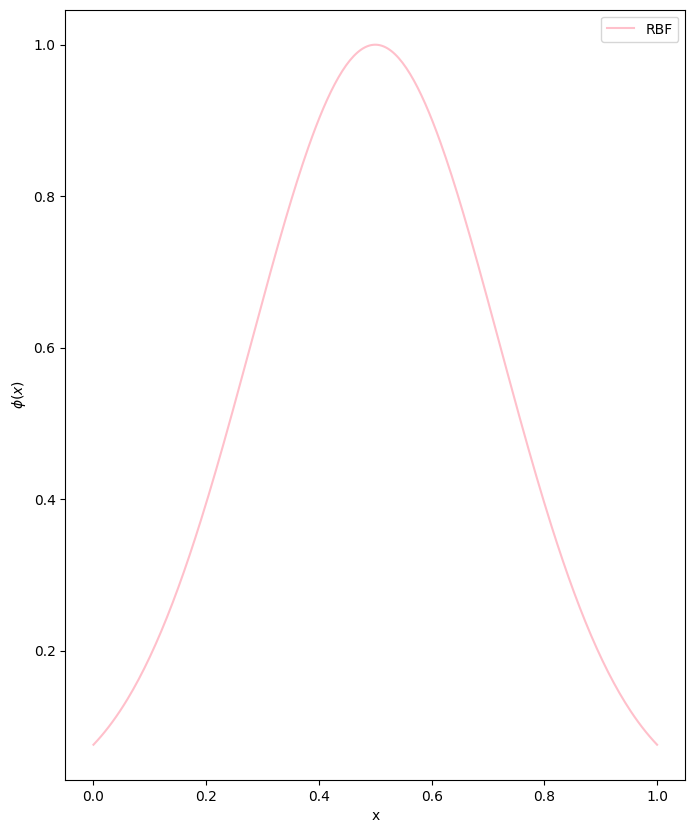

In [2169]:
X=np.linspace(0,1,300)
phi= RBF(X,0.5,0.22)
plt.figure(figsize=(8,10))
plt.plot(X,phi,color='pink',label='RBF')
plt.xlabel('x')
plt.ylabel(r"$\phi(x)$")
plt.legend()
plt.show()

In [2170]:
M=10
centros=np.random.rand(M)
sigma=0.1

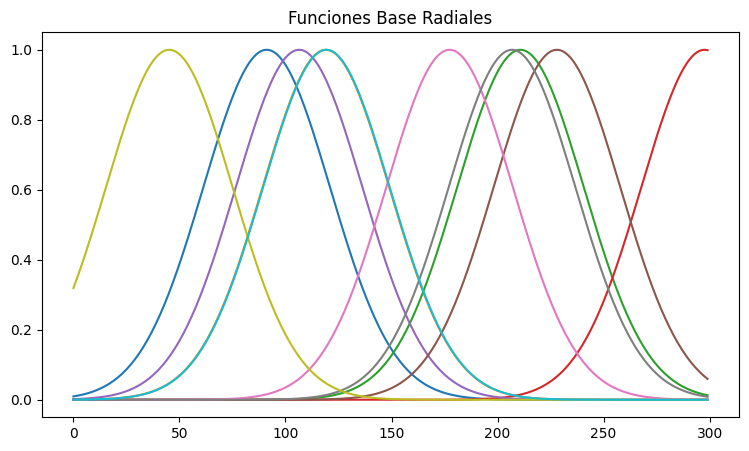

In [2171]:
X=np.linspace(0,1,300)

plt.figure(figsize=(9,5))

for c in centros:
    plt.plot(RBF(X,c,sigma))

plt.title("Funciones Base Radiales")

plt.show()

In [2172]:
def matriz_design(x,centros,sigma):
  phi=np.zeros((int(len(x)),int(len(centros))))
  for i,c in enumerate(centros):
    phi[:,i]=RBF(x,c,sigma)
  return phi

In [2173]:
phi=matriz_design(x,centros,sigma)
phi.shape

(40, 10)

In [2174]:
w=np.linalg.inv(phi.T@phi)@phi.T@y

In [2175]:
x_grid=np.linspace(0,1.25,300)
phi_test=matriz_design(x_grid,centros,sigma)
y_pred=phi_test@w
y_pred_rbf=y_pred


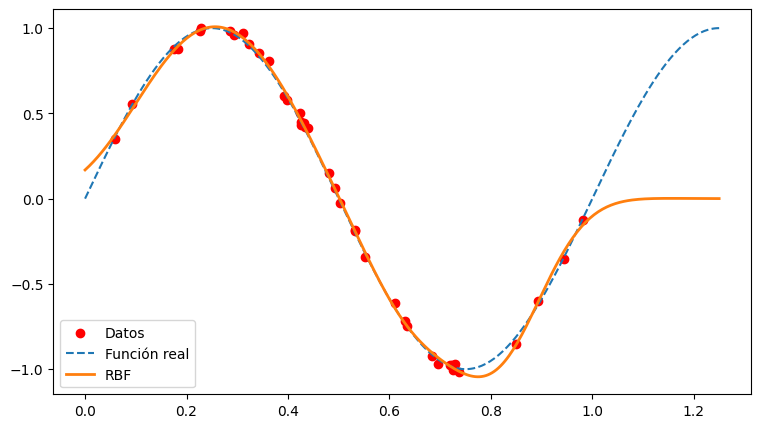

In [2176]:
plt.figure(figsize=(9,5))

plt.scatter(x,y,color="red",label="Datos")

plt.plot(x_grid,
         np.sin(2*np.pi*x_grid),
         '--',
         label="Función real")

plt.plot(x_grid,
         y_pred,
         linewidth=2,
         label="RBF")

plt.legend()

plt.show()

In [2177]:
alpha = 1

beta = 250

In [2178]:
M = phi.shape[1]

I = np.eye(M)

SN = np.linalg.inv(alpha*I + beta*phi.T@phi)

mN = beta*SN@phi.T@y

In [2179]:
med=phi_test@mN

In [2180]:
var = np.zeros(len(x_grid))

for i in range(len(x_grid)):

    Phi = phi_test[i,:]

    var[i] = 1/beta + Phi.T@SN@Phi

In [2181]:
std=np.sqrt(var)
std_bayes=std

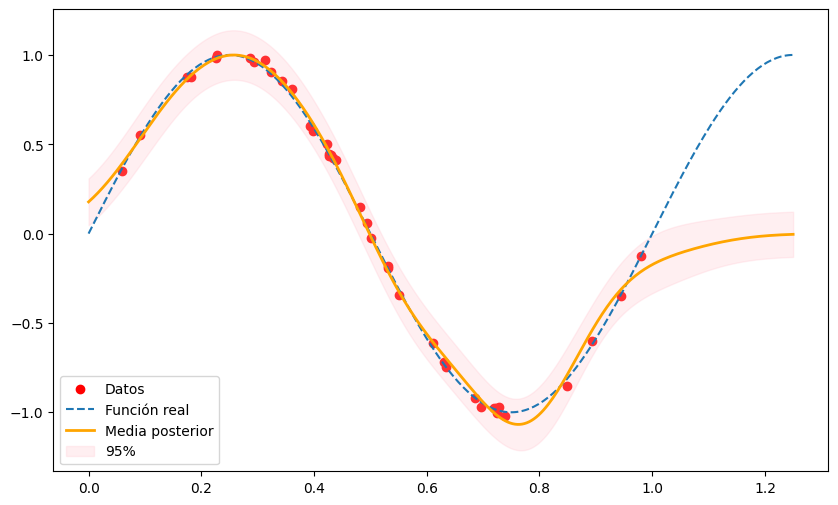

In [2182]:
plt.figure(figsize=(10,6))

plt.scatter(x,y,color="red",label="Datos")

plt.plot(
    x_grid,
    np.sin(2*np.pi*x_grid),
    "--",
    label="Función real"
)

plt.plot(
    x_grid,
    med,
    color="orange",
    linewidth=2,
    label="Media posterior"
)

plt.fill_between(
    x_grid,
    med-2*std,
    med+2*std,
    color="pink",
    alpha=0.25,
    label="95%"
)

plt.legend()

plt.show()

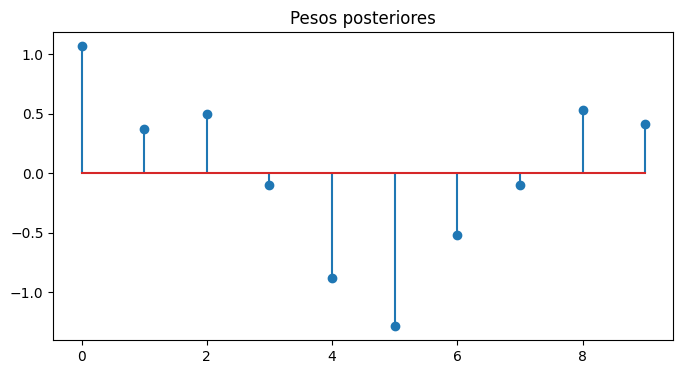

In [2183]:
plt.figure(figsize=(8,4))

plt.stem(mN)

plt.title("Pesos posteriores")

plt.show()

In [2184]:
samples = np.random.multivariate_normal(
    mN,
    SN,
    5
)

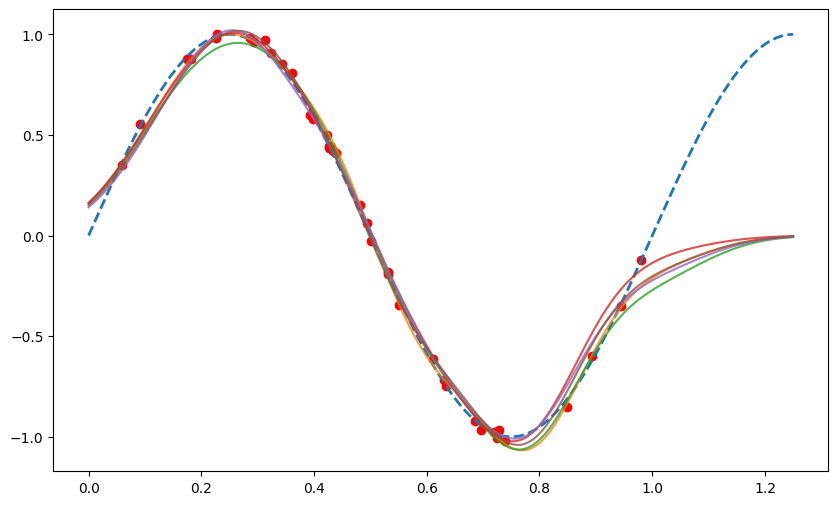

In [2185]:
plt.figure(figsize=(10,6))

plt.scatter(x,y,color="red")

plt.plot(x_grid,
         np.sin(2*np.pi*x_grid),
         "--",
         linewidth=2)

for w in samples:

    plt.plot(
        x_grid,
        phi_test@w,
        alpha=0.8
    )

plt.show()

In [2186]:
samples = np.random.multivariate_normal(mN, SN, 100)

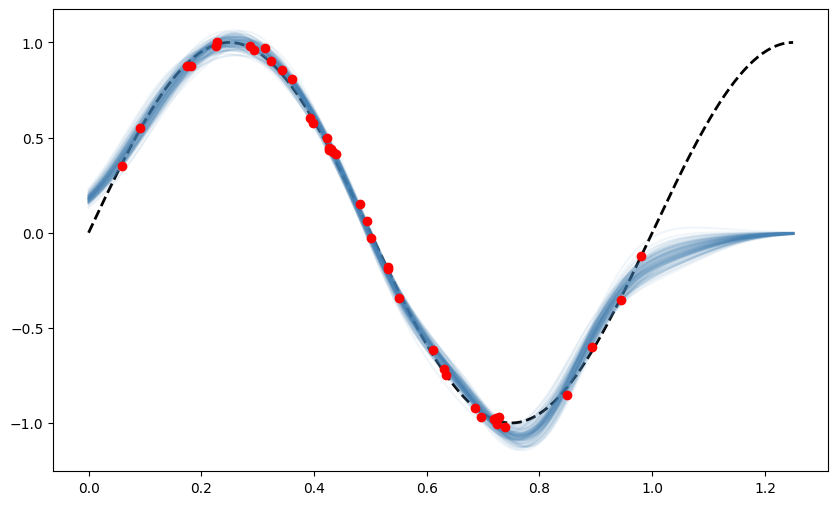

In [2187]:
plt.figure(figsize=(10,6))

plt.scatter(x, y, color="red", zorder=3)

plt.plot(x_grid, np.sin(2*np.pi*x_grid), "k--", lw=2)

for w in samples:
    plt.plot(x_grid, phi_test @ w, color="steelblue", alpha=0.08)

plt.show()

In [2188]:
'NADAYARA WATSON'

'NADAYARA WATSON'

In [2189]:
def NADWAT(x,a,y,c):
  w=RBF(x,a,c)
  return np.sum(w*y)/np.sum(w)

In [2190]:
x_grid=np.linspace(0,1.25,300)

prediction=np.zeros_like(x_grid)

for i,x_val in enumerate(x_grid):

    prediction[i]=NADWAT(
        x_val,
        x,
        y,
        c=0.05
    )

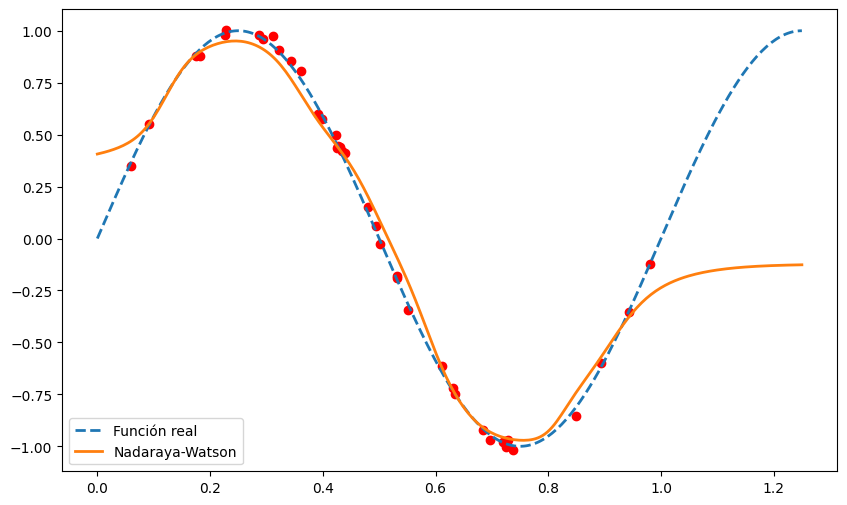

In [2191]:
plt.figure(figsize=(10,6))

plt.scatter(x,y,color="red")

plt.plot(
    x_grid,
    np.sin(2*np.pi*x_grid),
    "--",
    linewidth=2,
    label="Función real"
)

plt.plot(
    x_grid,
    prediction,
    linewidth=2,
    label="Nadaraya-Watson"
)

plt.legend()

plt.show()

In [2192]:
'Matriz kernel'
def kernel_matriz(x,s):
  n=len(x)
  k=np.zeros((n,n))
  for i in range(n):
    for j in range(n):
      k[i,j]=RBF(x[i],x[j],s)
  return k


In [2193]:
k=kernel_matriz(x,0.10)

In [2194]:
k

array([[1.00000000e+00, 9.48782536e-01, 5.11616823e-01, ...,
        8.06583865e-16, 1.02892587e-17, 3.77770998e-19],
       [9.48782536e-01, 1.00000000e+00, 7.06568879e-01, ...,
        1.14267384e-14, 1.71852896e-16, 7.10477997e-18],
       [5.11616823e-01, 7.06568879e-01, 1.00000000e+00, ...,
        6.41933866e-12, 1.47401003e-13, 8.26781209e-15],
       ...,
       [8.06583865e-16, 1.14267384e-14, 6.41933866e-12, ...,
        1.00000000e+00, 8.79075944e-01, 6.82686288e-01],
       [1.02892587e-17, 1.71852896e-16, 1.47401003e-13, ...,
        8.79075944e-01, 1.00000000e+00, 9.35201467e-01],
       [3.77770998e-19, 7.10477997e-18, 8.26781209e-15, ...,
        6.82686288e-01, 9.35201467e-01, 1.00000000e+00]])

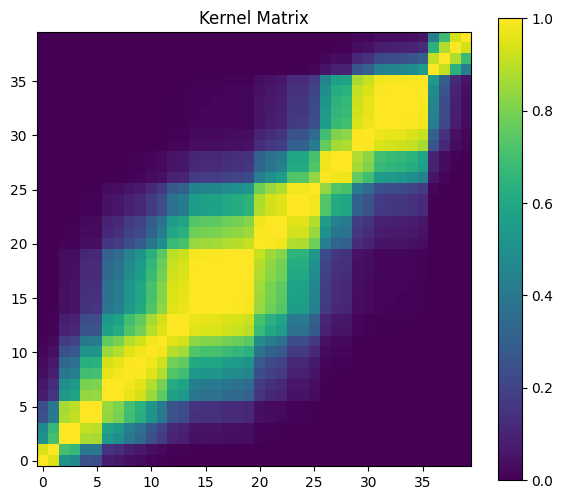

In [2195]:
plt.figure(figsize=(7,6))

plt.imshow(k,
           cmap="viridis",
           origin="lower")

plt.colorbar()

plt.title("Kernel Matrix")

plt.show()

In [2196]:
sigma = 0.20

C = k + sigma**2*np.eye(len(x))

In [2197]:
print(np.linalg.cond(C))

354.6256403108372


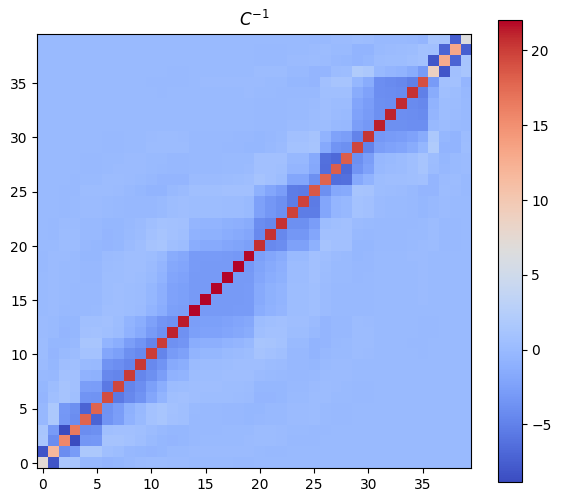

In [2198]:
Kinv = np.linalg.inv(C)

plt.figure(figsize=(7,6))

plt.imshow(Kinv,
           cmap="coolwarm",
           origin="lower")

plt.colorbar()

plt.title(r"$C^{-1}$")

plt.show()

In [2199]:
x_grid = np.linspace(0,1,200)

K = kernel_matriz(x_grid,0.1)

samples = np.random.multivariate_normal(
    np.zeros(len(x_grid)),
    K,
    5
)

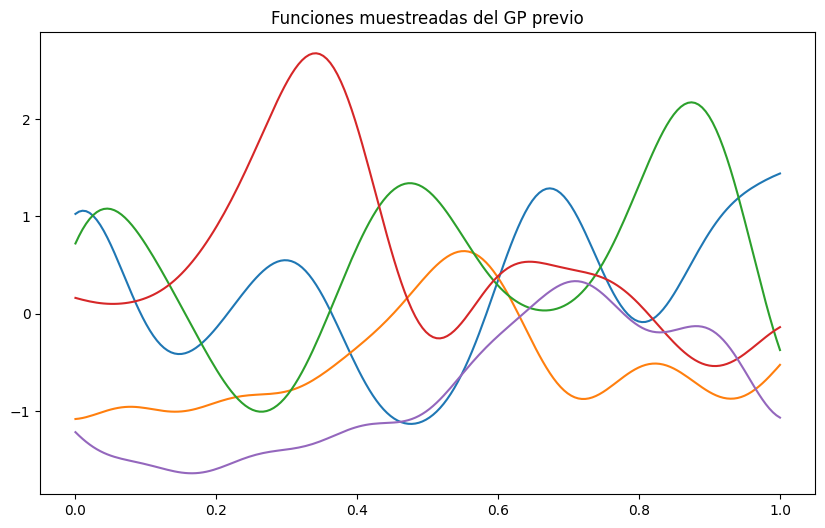

In [2200]:
plt.figure(figsize=(10,6))

for s in samples:

    plt.plot(x_grid,s)

plt.title("Funciones muestreadas del GP previo")

plt.show()

In [2201]:
def kernel_matrix(X1, X2, l=0.15, sigma_f=1.0):

    X1 = np.atleast_2d(X1).T
    X2 = np.atleast_2d(X2).T

    sqdist = (X1-X2.T)**2

    return sigma_f**2*np.exp(-sqdist/(2*l**2))

In [2202]:
x_grid = np.linspace(0,1.25,300)

In [2203]:
C = kernel_matrix(x,x,l,theta_0) + (1/beta)*np.eye(len(x))

In [2204]:
k= kernel_matrix(x,x_grid,l,theta_0)

In [2205]:
c= kernel_matrix(x_grid,x_grid,l, theta_0) + (1/beta)*np.eye(len(x_grid))

In [2206]:
mean=k.T@np.linalg.solve(C,y)

In [2207]:
media_gpbayes=mean

In [2208]:
cov=c-k.T@np.linalg.solve(C,k)

In [2209]:
print(k.shape)
print(C.shape)
print(c.shape)

(40, 300)
(40, 40)
(300, 300)


In [2210]:
std=np.diag(cov)
std_gpbayes=std

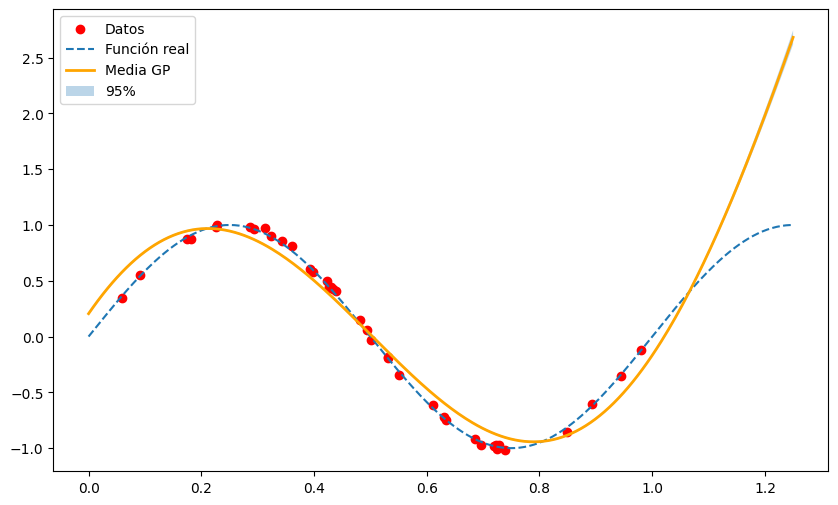

In [2211]:
plt.figure(figsize=(10,6))

plt.scatter(
    x,
    y,
    color="red",
    label="Datos"
)

plt.plot(
    x_grid,
    np.sin(2*np.pi*x_grid),
    "--",
    label="Función real"
)

plt.plot(
    x_grid,
    mean,
    color="orange",
    lw=2,
    label="Media GP"
)

plt.fill_between(
    x_grid,
    mean-2*std,
    mean+2*std,
    alpha=0.30,
    label="95%"
)

plt.legend()

plt.show()

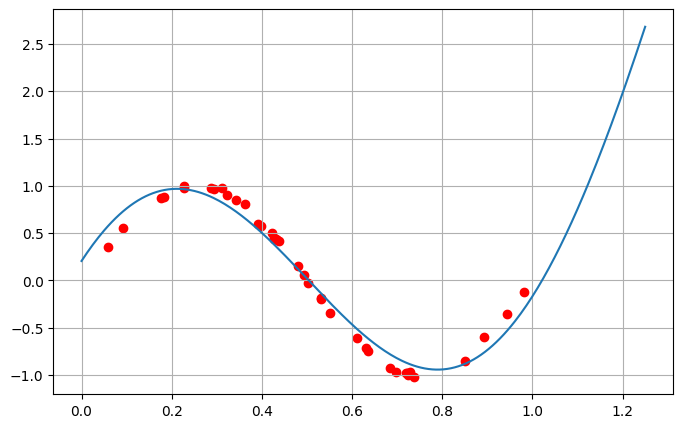

In [2212]:
plt.figure(figsize=(8,5))

plt.plot(x_grid, mean)

plt.scatter(x,y,color="red")

plt.grid()

plt.show()

In [2213]:
x_test = np.array([1.25])

k = kernel_matrix(
        x,
        x_test,
        l_opt,
        theta0_opt
    )

media = k.T @ np.linalg.solve(C, y)

print(media)

[33.27297774]


In [2214]:
print(theta0_opt)
print(l_opt)

print(kernel_matrix(
    np.array([1.0]),
    np.array([1.25]),
    l_opt,
    theta0_opt
))

1.4084502051976553
0.35610059601914174
[[1.55044757]]


In [2215]:
samples = np.random.multivariate_normal(
    mean,
    cov,
    5
)

In [2216]:
samples.shape

(5, 300)

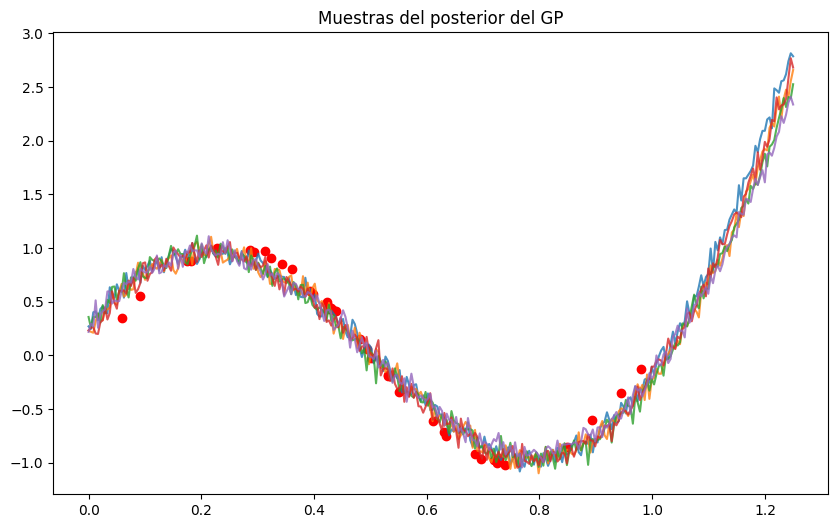

In [2217]:
plt.figure(figsize=(10,6))

plt.scatter(
    x,
    y,
    color="red"
)

for s in samples:

    plt.plot(
        x_grid,
        s,
        alpha=0.8
    )

plt.title("Muestras del posterior del GP")

plt.show()

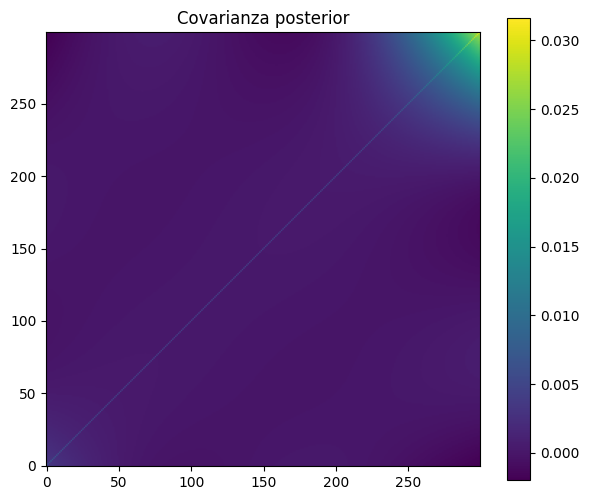

In [2218]:
plt.figure(figsize=(7,6))

plt.imshow(
    cov,
    origin="lower",
    cmap="viridis"
)

plt.colorbar()

plt.title("Covarianza posterior")

plt.show()

In [2219]:
def log_marginal_likelihood(l,
                            X,
                            y,
                            theta0,
                            beta):

    K = kernel_matrix(
        X,
        X,
        l,
        theta0
    )

    C = K + (1/beta)*np.eye(len(X))

    sign, logdet = np.linalg.slogdet(C)

    quad = y.T @ np.linalg.solve(C,y)

    N = len(X)

    return (
        -0.5*logdet
        -0.5*quad
        -0.5*N*np.log(2*np.pi)
    )

In [2220]:
l_values = np.linspace(
    0.02,
    0.80,
    150
)

loglik = []

In [2221]:
for l in l_values:

    loglik.append(

        log_marginal_likelihood(

            l,

            x,

            y,

            theta_0,

            beta
        )
    )

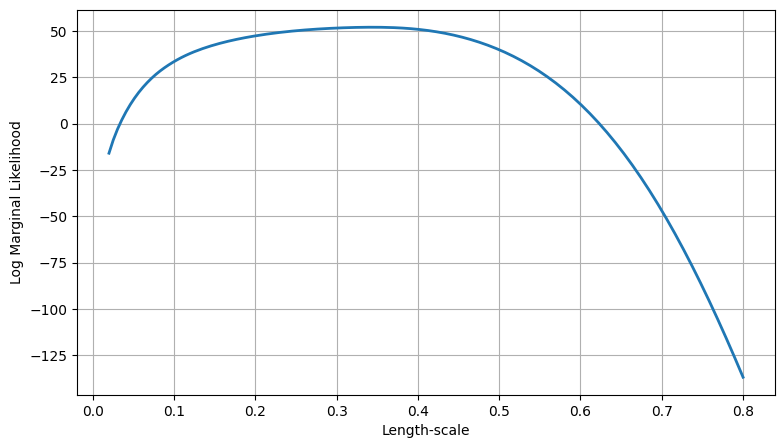

In [2222]:
plt.figure(figsize=(9,5))

plt.plot(
    l_values,
    loglik,
    linewidth=2
)

plt.xlabel("Length-scale")

plt.ylabel("Log Marginal Likelihood")

plt.grid()

plt.show()

In [2223]:
best_index = np.argmax(loglik)

l_opt = l_values[best_index]

print(l_opt)

0.3445637583892618


In [2224]:
from scipy.optimize import minimize

In [2225]:
def negative_log_marginal_likelihood(params,
                                     X,
                                     y):

    theta0 = params[0]
    l      = params[1]
    beta   = params[2]

    # Evitar valores no válidos
    if theta0 <= 0 or l <= 0 or beta <= 0:
        return np.inf

    K = kernel_matrix(
            X,
            X,
            l,
            theta0
        )

    C = K + (1/beta)*np.eye(len(X))

    sign, logdet = np.linalg.slogdet(C)

    quad = y.T @ np.linalg.solve(C,y)

    N = len(X)

    loglik = (
        -0.5*logdet
        -0.5*quad
        -0.5*N*np.log(2*np.pi)
    )

    return -loglik

In [2226]:
params0 = np.array([
    1.0,
    0.15,
    20
])

In [2227]:
negative_log_marginal_likelihood(params0,x,y)

np.float64(-7.281330794386328)

In [2228]:
result = minimize(
            negative_log_marginal_likelihood,
            params0,
            args=(x,y),
            method="L-BFGS-B",
            bounds=[
                (1e-3,None),
                (1e-3,None),
                (1e-3,None)
            ]
)

In [2229]:
theta0_opt = result.x[0]
l_opt      = result.x[1]
beta_opt   = result.x[2]

In [2230]:
print(theta0_opt)
print(l_opt)
print(beta_opt)

1.4084502051976553
0.35610059601914174
2001.9623873874173


In [2231]:
import numpy as np

np.random.seed(123)

N = 120

x1 = np.random.rand(N)

x2 = x1 + np.random.normal(0,0.20,N)

x3 = np.random.rand(N)

y = np.sin(2*np.pi*x1) + np.random.normal(0,0.10,N)

In [2232]:
X = np.column_stack((x1,x2,x3))

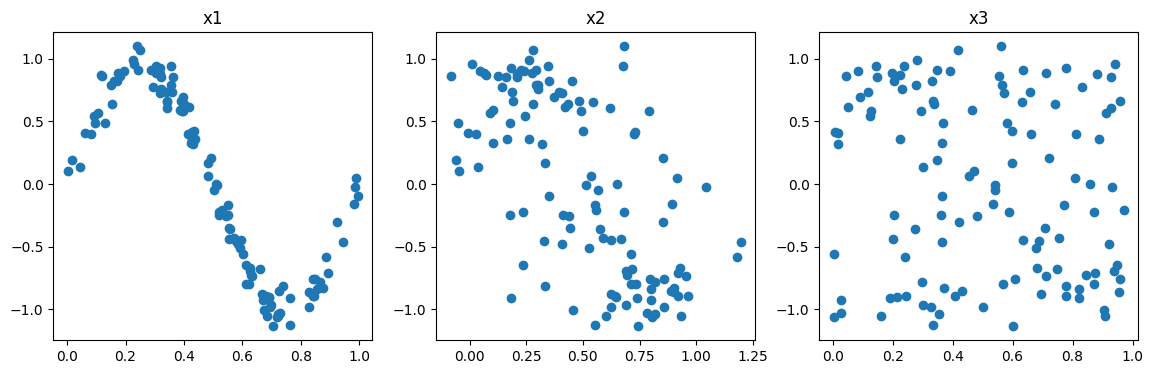

In [2233]:
fig,ax=plt.subplots(1,3,figsize=(14,4))

ax[0].scatter(x1,y)

ax[0].set_title("x1")

ax[1].scatter(x2,y)

ax[1].set_title("x2")

ax[2].scatter(x3,y)

ax[2].set_title("x3")

plt.show()

In [2234]:
def ard_kernel(X1,
               X2,
               theta0,
               eta):

    X1 = np.atleast_2d(X1)
    X2 = np.atleast_2d(X2)

    dist = np.zeros((len(X1),len(X2)))

    for d in range(X1.shape[1]):

        dist += eta[d]*(

            X1[:,d][:,None]-X2[:,d]

        )**2

    return theta0*np.exp(-0.5*dist)

In [2235]:
X[:,0][:,None].shape

(120, 1)

In [2236]:
X[:,0].shape

(120,)

In [2237]:
X.shape

(120, 3)

In [2238]:
eta=np.array([8,1,1])

In [2239]:
K=ard_kernel(
    X,
    X,
    1,
    eta
)

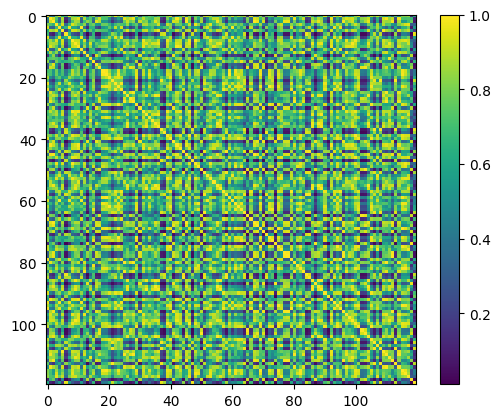

In [2240]:
plt.imshow(K)
plt.colorbar()
plt.show()

In [2241]:
def negative_log_marginal_ard(params,
                              X,
                              y):

    theta0 = params[0]

    eta = params[1:4]

    beta = params[4]

    if theta0<=0 or beta<=0 or np.any(eta<=0):

        return np.inf

    K = ard_kernel(
            X,
            X,
            theta0,
            eta
        )

    C = K + (1/beta)*np.eye(len(X))

    sign, logdet = np.linalg.slogdet(C)

    quad = y.T @ np.linalg.solve(C,y)

    N = len(X)

    loglik = (
        -0.5*logdet
        -0.5*quad
        -0.5*N*np.log(2*np.pi)
    )

    return -loglik

In [2242]:
params0 = np.array([

    1.0,

    1.0,

    1.0,

    1.0,

    25

])

In [2243]:
result = minimize(

    negative_log_marginal_ard,

    params0,

    args=(X,y),

    method="L-BFGS-B",

    bounds=[

        (1e-4,None),

        (1e-4,None),

        (1e-4,None),

        (1e-4,None),

        (1e-4,None)

    ]

)

In [2244]:
theta0 = result.x[0]

eta = result.x[1:4]

beta = result.x[4]

In [2245]:
print("theta0 =",theta0)

print("beta =",beta)

print()

print("eta =",eta)

theta0 = 1.4313981533053832
beta = 116.41183553453969

eta = [9.24010822e+00 1.00000000e-04 1.00000000e-04]


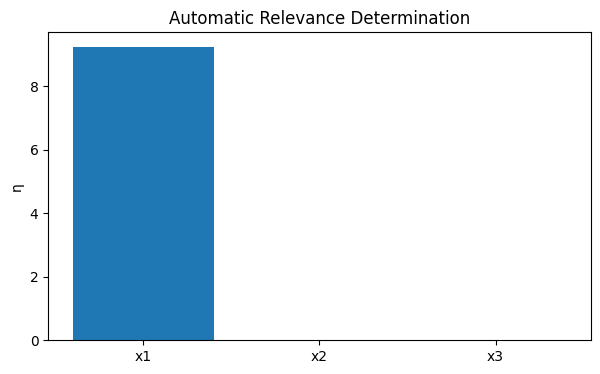

In [2246]:
plt.figure(figsize=(7,4))

plt.bar(

    ["x1","x2","x3"],

    eta

)

plt.ylabel("η")

plt.title("Automatic Relevance Determination")

plt.show()

In [2247]:
np.random.seed(15)

N = 40

x = np.sort(np.random.rand(N))

y = np.sin(2*np.pi*x) + np.random.normal(0,0.2,N)

x_grid = np.linspace(0,1.25,400)

In [2248]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Crear el modelo polinomial de grado 2
modelo_polinomial = make_pipeline(PolynomialFeatures(degree=5), LinearRegression())
modelo_lineal=LinearRegression()

# Entrenar el modelo directamente

modelo_polinomial.fit(x.reshape(-1, 1), y)
modelo_lineal.fit(x.reshape(-1, 1), y)

LinearRegression()

In [2249]:
y_pol=modelo_polinomial.predict(x_grid.reshape(-1, 1))

In [2250]:
y_lin=modelo_lineal.predict(x_grid.reshape(-1, 1))

In [2251]:
y_pred_rbf

array([ 1.68233937e-01,  1.79798066e-01,  1.91864978e-01,  2.04432715e-01,
        2.17497350e-01,  2.31052930e-01,  2.45091445e-01,  2.59602807e-01,
        2.74574838e-01,  2.89993285e-01,  3.05841840e-01,  3.22102180e-01,
        3.38754021e-01,  3.55775184e-01,  3.73141680e-01,  3.90827803e-01,
        4.08806237e-01,  4.27048173e-01,  4.45523434e-01,  4.64200614e-01,
        4.83047211e-01,  5.02029782e-01,  5.21114083e-01,  5.40265227e-01,
        5.59447828e-01,  5.78626155e-01,  5.97764279e-01,  6.16826211e-01,
        6.35776045e-01,  6.54578084e-01,  6.73196971e-01,  6.91597801e-01,
        7.09746232e-01,  7.27608587e-01,  7.45151942e-01,  7.62344216e-01,
        7.79154243e-01,  7.95551838e-01,  8.11507862e-01,  8.26994272e-01,
        8.41984168e-01,  8.56451832e-01,  8.70372767e-01,  8.83723721e-01,
        8.96482717e-01,  9.08629070e-01,  9.20143408e-01,  9.31007680e-01,
        9.41205172e-01,  9.50720506e-01,  9.59539648e-01,  9.67649902e-01,
        9.75039909e-01,  

In [2252]:
y_pred_bayesrbf=med

In [2253]:
std_bayes

array([0.06555153, 0.06582679, 0.0661228 , 0.06643921, 0.06677537,
       0.06713028, 0.06750253, 0.06789037, 0.06829164, 0.06870377,
       0.06912385, 0.06954862, 0.06997448, 0.07039757, 0.07081382,
       0.07121898, 0.07160872, 0.07197868, 0.07232458, 0.07264227,
       0.07292785, 0.07317773, 0.07338874, 0.07355819, 0.07368396,
       0.07376457, 0.07379926, 0.073788  , 0.07373157, 0.07363154,
       0.07349031, 0.07331108, 0.07309777, 0.07285505, 0.07258813,
       0.07230277, 0.07200503, 0.07170123, 0.07139766, 0.07110051,
       0.07081557, 0.07054812, 0.07030275, 0.07008315, 0.06989203,
       0.06973102, 0.06960065, 0.06950031, 0.06942833, 0.06938207,
       0.0693581 , 0.0693523 , 0.06936013, 0.06937682, 0.06939758,
       0.06941783, 0.06943339, 0.06944062, 0.0694366 , 0.06941923,
       0.06938723, 0.06934023, 0.06927868, 0.06920385, 0.06911765,
       0.06902256, 0.0689214 , 0.06881724, 0.06871311, 0.0686119 ,
       0.06851615, 0.06842791, 0.06834862, 0.06827905, 0.06821

In [2254]:
y_pred_ndw=prediction

In [2255]:
media_gpbayes, std_gpbayes

(array([ 0.20529807,  0.23554744,  0.26519659,  0.29424316,  0.32268488,
         0.35051966,  0.37774552,  0.40436063,  0.43036329,  0.45575196,
         0.48052522,  0.50468178,  0.52822052,  0.55114044,  0.5734407 ,
         0.59512057,  0.61617949,  0.63661704,  0.65643293,  0.67562703,
         0.69419934,  0.71215   ,  0.72947932,  0.74618772,  0.76227578,
         0.77774422,  0.79259393,  0.8068259 ,  0.82044129,  0.8334414 ,
         0.84582767,  0.8576017 ,  0.8687652 ,  0.87932006,  0.88926829,
         0.89861205,  0.90735364,  0.9154955 ,  0.92304021,  0.92999051,
         0.93634925,  0.94211945,  0.94730424,  0.95190691,  0.95593088,
         0.95937971,  0.96225711,  0.96456689,  0.96631302,  0.96749962,
         0.96813091,  0.96821126,  0.96774518,  0.96673728,  0.96519235,
         0.96311526,  0.96051103,  0.9573848 ,  0.95374186,  0.94958759,
         0.94492751,  0.93976726,  0.9341126 ,  0.92796941,  0.9213437 ,
         0.91424158,  0.90666928,  0.89863315,  0.8

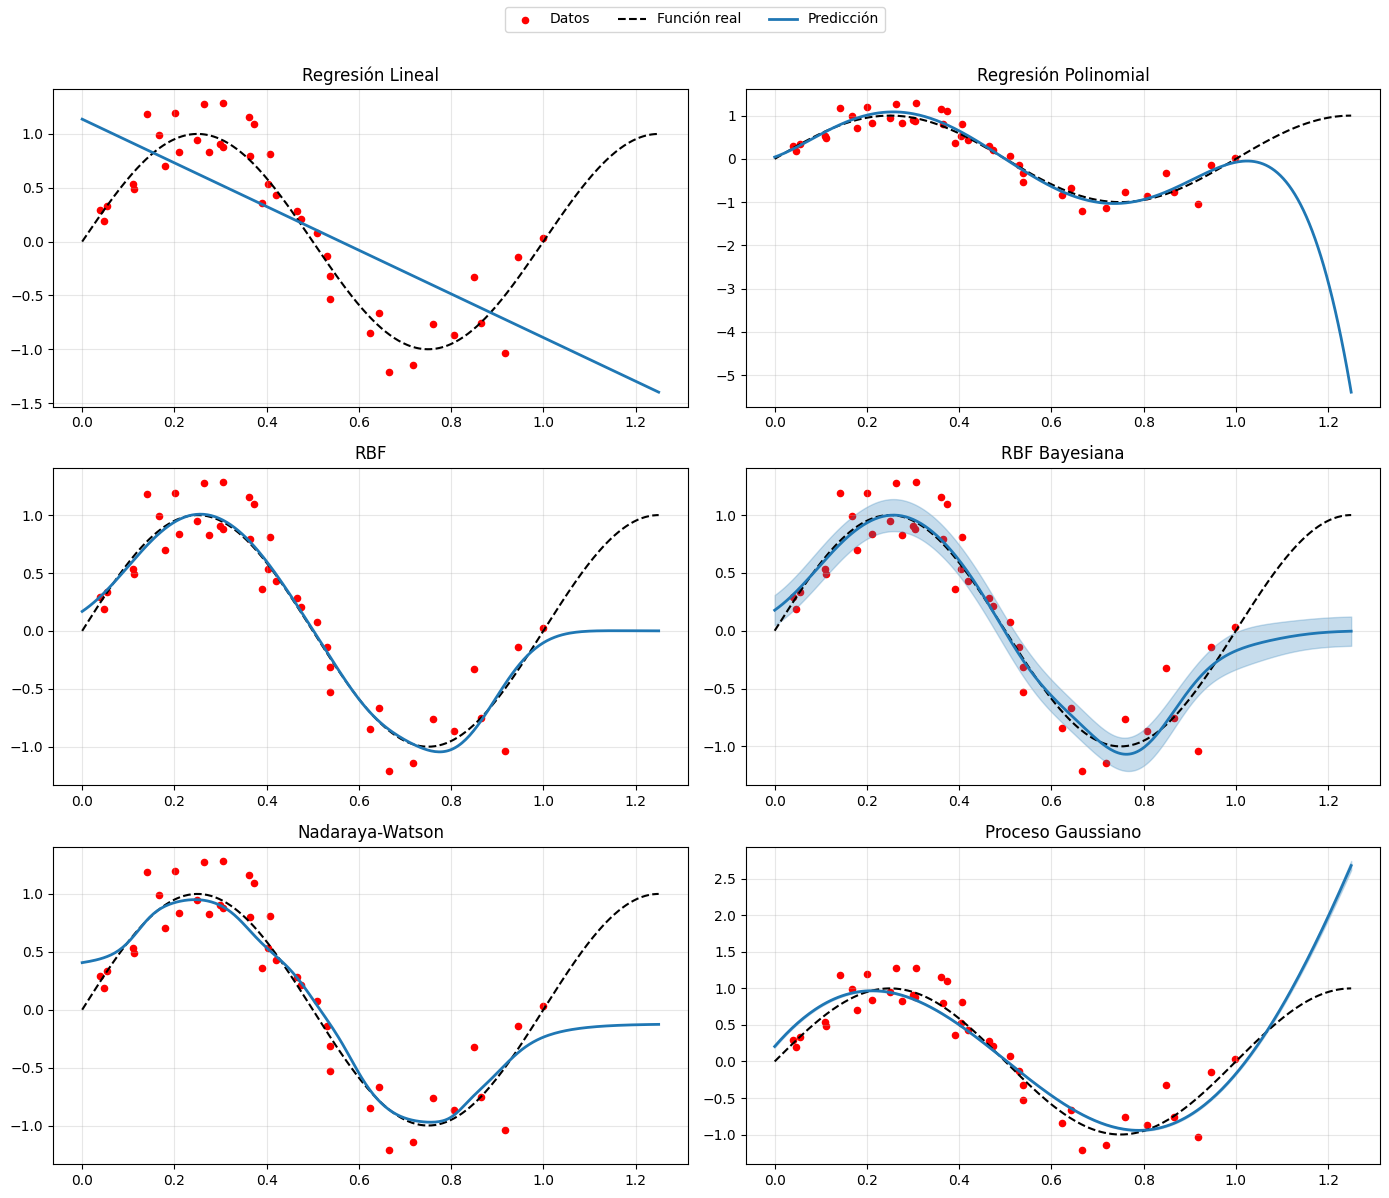

In [2256]:
fig, axs = plt.subplots(3, 2, figsize=(14, 12))

# Define the x_grids used for different models during their calculation
x_grid_400 = np.linspace(0,1.25,400) # Current x_grid used for y_lin and y_pol
x_grid_0_to_1_25_300_for_rbf_bayes_gp = np.linspace(0,1.25,300) # Used for RBF, RBF Bayesian, Gaussian Process
x_grid_0_to_1_300_for_ndw = np.linspace(0,1.25,300) # Used for Nadaraya-Watson

modelos = [
    ("Regresión Lineal", y_lin, None, x_grid_400),
    ("Regresión Polinomial", y_pol, None, x_grid_400),
    ("RBF", y_pred_rbf, None, x_grid_0_to_1_25_300_for_rbf_bayes_gp),
    ("RBF Bayesiana", y_pred_bayesrbf, std_bayes, x_grid_0_to_1_25_300_for_rbf_bayes_gp),
    ("Nadaraya-Watson", y_pred_ndw, None, x_grid_0_to_1_300_for_ndw),
    ("Proceso Gaussiano", media_gpbayes, std_gpbayes, x_grid_0_to_1_25_300_for_rbf_bayes_gp)
]

for ax, (titulo, pred, std, current_x_grid) in zip(axs.ravel(), modelos):

    # Datos
    ax.scatter(x, y,
               color="red",
               s=20,
               label="Datos")

    # Función verdadera
    ax.plot(current_x_grid,
            np.sin(2*np.pi*current_x_grid),
            "--",
            color="black",
            label="Función real")

    # Predicción
    ax.plot(current_x_grid,
            pred,
            color="tab:blue",
            linewidth=2,
            label="Predicción")

    # Intervalo de confianza (solo modelos bayesianos)
    if std is not None:

        ax.fill_between(
            current_x_grid,
            pred - 2*std,
            pred + 2*std,
            alpha=0.25,
            color="tab:blue",
            label="95%"
        )

    ax.set_title(titulo)
    ax.grid(alpha=0.3)

# Una sola leyenda
handles, labels = axs[0,0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="upper center",
           ncol=4)

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

In [2257]:
print(theta0_opt)
print(l_opt)
print(beta_opt)

1.4084502051976553
0.35610059601914174
2001.9623873874173


In [2258]:
print(f"theta0 = {theta0_opt:.6f}")
print(f"l      = {l_opt:.6f}")
print(f"beta   = {beta_opt:.6f}")

theta0 = 1.408450
l      = 0.356101
beta   = 2001.962387
